<a href="https://colab.research.google.com/github/aalarina/cnn-image-classification-pytorch/blob/main/CNN_image_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task description**

We have a set of generated images. Some of the generated images contain various types of artifacts, including but not limited to text, hands, fingers, pieces of masks, tattoos, eyes that do not look at the camera, etc. This task is a Kaggle-like challenge to train the best possible model for classifying binary images.


# Requirements for implementation:

## Preprocessing:

* Perform image augmentation (be sure to use at least two different methods).

* Display examples of augmented images.

* Resize images — for example, to 224×224 pixels, orto another size that suits your PC's capabilities. This can beadded to the augmentation immediately.

* Build PyTorch Dataset and DataLoader.




## Dataset Extraction

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/deep_learning_project/dl_dataset.zip'
extract_path = '/content/data'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Data unpacked!")
else:
    print("⚡ The data has already been unpacked.")

✅ Data unpacked!


After extracting the dataset, the next step is to confirm that the files were unpacked correctly and that the expected folder structure is present. This is done using a simple directory listing command.

In [ ]:
# Check the structure
os.listdir("data")

['trainee_dataset']

## Importing Libraries and Dependencies

This code block imports all the required Python packages for data handling, model training, image processing, and evaluation. These imports form the foundation of the entire deep learning pipeline.

In [ ]:
import os, re, random, copy
from glob import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

**Setting a Random Seed**

Deep learning models involve randomization — in weight initialization, data shuffling, and sometimes in operations inside the framework.
To make the results consistent across multiple runs, the script sets the same random seed across all involved libraries.

In [ ]:
# Set SEED
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

* `random.seed(SEED)` — ensures Python's built-in random module behaves consistently.

* `np.random.seed(SEED)` — ensures reproducibility for NumPy operations.

* `torch.manual_seed(SEED)` — ensures deterministic behavior for PyTorch CPU and GPU ops.




In [ ]:

# PyTorch deterministic mode
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")

print(f"✅ Seed set to: {SEED}")
print(f"💻 Device: {DEVICE}")

✅ Seed set to: 42
💻 Device: cpu


* ` torch.backends.cudnn.deterministic = True`: forces deterministic algorithms for operations executed on CUDA.

* `torch.backends.cudnn.benchmark = False`: disables algorithm optimization search that may introduce randomness.

## Data preparation

This helper function extracts image file paths and their corresponding labels from a directory. It relies on a specific filename format to automatically parse labels without requiring a separate annotations file.

In [ ]:
# Helpers: read filenames and labels

def get_image_list_from_dir(directory):
  """Assumes files named like image_<frame_index>_<label>.png"""
  files = sorted(glob(os.path.join(directory, '*.png')))
  items = []
  for f in files:
    name = os.path.basename(f)
    parts = name.split('_')
    # label expected as last part like '0.png' or '1.png'
    label_part = parts[-1]
    label = int(label_part.split('.')[0])
    items.append((f, label))
  return items

* The function expects files named in a pattern such as: image_001_0.png, image_120_1.png, etc.

* `glob()` retrieves all .png files in the directory.

* `sorted()` ensures a deterministic order of files.

### Defining Dataset Paths

In [ ]:
# Define paths to your train and test directories
TRAIN_DIR = '/content/data/trainee_dataset/train'
TEST_DIR = '/content/data/trainee_dataset/test'

*   TRAIN_DIR — labeled images used for training and validation.

* TEST_DIR — images used only for final model evaluation.



In [ ]:
# Complete list of all training images with their corresponding labels.
all_items = get_image_list_from_dir(TRAIN_DIR)

The result is a list of tuples.

```
[(file_path_1, label_1),
 (file_path_2, label_2),
 ...]
```




### Preparing the Train and Val Dataset

In [ ]:
# Split the data for training and validation
files = [f for f, _ in all_items]
labels = [l for _, l in all_items]

train_files, val_files, train_labels, val_labels = train_test_split(
    files, labels, test_size=0.2, stratify=labels, random_state=SEED
)

print(f"Train size: {len(train_files)}, Val size: {len(val_files)}")

Train size: 1440, Val size: 360


* `test_size=0.2` → 20% of the training data is used for validation.

* `stratify=labels` → ensures class balance is preserved in both splits.

* `random_state=SEED` → guarantees reproducibility.

**Inspecting Class Distribution**

Before training a machine learning model, it is crucial to verify whether the dataset is balanced, because an imbalanced dataset can lead the model to overfit the majority class and perform poorly on the minority class.

In [ ]:
# Check class distribution
count_class0 = sum(np.array(train_labels) == 0)
count_class1 = sum(np.array(train_labels) == 1)
print(f"Train label count: class0={count_class0}, class1={count_class1}")

Train label count: class0=144, class1=1296


**Interpretation**

* Class 0 (minority) has 144 samples.

* Class 1 (majority) has 1296 samples.

This is roughly a 1:9 ratio, which is a significant imbalance.

The model may overfit to the majority class and struggle to correctly classify the minority class.

Special care may be needed during training:

* Class weighting in the loss function.

* Oversampling the minority class.

* Undersampling the majority class.

* Advanced techniques like SMOTE or focal loss for imbalanced data.

### Preparing the Test Dataset

In [ ]:
test_items = get_image_list_from_dir(TEST_DIR)
test_files = [f for f, l in test_items]
test_labels = [l for f, l in test_items]

print(f"Test size: {len(test_files)}")
print(f"First 5 labels: {test_labels[:5]}")

Test size: 200
First 5 labels: [1, 1, 0, 0, 1]


## Data augmentation

Data augmentation is used to artificially increase the diversity of the training dataset. This is especially important for imbalanced datasets like ours, where class 0 has far fewer samples than class 1.

In [ ]:
# Augmentation setup
IMG_SIZE = 224

# We'll define two augmentation "methods" and ensure class 0 is oversampled
transform_0 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Simple transform for label 1 (clean images)
transform_1 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Enhances class 0 samples by generating more diverse training examples.
\
Class 1 images are already abundant, so heavy augmentation is unnecessary.

* Resize → standardizes image size.

* RandomHorizontalFlip → flips images horizontally randomly.

* RandomRotation(45) → rotates images up to ±45° to simulate different orientations.

* ColorJitter → changes brightness, contrast, and saturation to add color variability.

* ToTensor → converts PIL images to PyTorch tensors.

* Normalize → scales pixel values using standard ImageNet mean and std, which is important for pretrained models.

**Validation and Test Transform**

For validation and test datasets, it is important not to apply random augmentations. This ensures that the model is evaluated on data that reflects the real distribution and is consistent across runs.

In [ ]:
# Validation / test transform (no augmentation)
val_transform = transforms.Compose([
transforms.Resize((IMG_SIZE, IMG_SIZE)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Custom PyTorch Dataset

To efficiently handle image data with class-dependent augmentations, a custom PyTorch Dataset is implemented. This allows seamless integration with PyTorch’s DataLoader for batching and shuffling.

In [ ]:
# Custom PyTorch Dataset for Artifact Detection

class ArtifactDataset(Dataset):
  def __init__(self,  files, labels, transform_0=None, transform_1=None, val_transform=None, train=True):
    """
    items: list of (filepath, label)
    """
    self.files = files   # list of image file paths
    self.labels = labels # corresponding class labels
    self.train = train   # flag to distinguish training vs. validation/test mode
    self.transform_0 = transform_0
    self.transform_1 = transform_1
    self.val_transform = val_transform

  def __len__(self): # Returns the total number of samples in the dataset
    return len(self.files)

  def __getitem__(self, idx):
    # Opens the image and converts it to RGB
    img_path = self.files[idx]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')

    # Conditional Transformations
    if self.train:  # Training mode
      if label == 0 and self.transform_0:
        image = self.transform_0(image)
      elif label == 1 and self.transform_1:
        image = self.transform_1(image)
    else:
      if self.val_transform: # Validation/Test mode
        image = self.val_transform(image)
      else:
        image = transforms.ToTensor()(image)

    return image, torch.tensor(label, dtype=torch.long)

**Creating Dataset Objects**

After defining the ArtifactDataset class, we instantiate it for training, validation, and testing. This prepares the data for use with PyTorch DataLoaders.

In [ ]:
train_dataset = ArtifactDataset(
    train_files,
    train_labels,
    transform_0,
    transform_1,
    train=True)

In [ ]:
val_dataset = ArtifactDataset(
    val_files,
    val_labels,
    val_transform=val_transform,
    train=False)

In [ ]:
test_dataset = ArtifactDataset(
    test_files,
    test_labels,
    transform_0=transform_0,
    transform_1=transform_1,
    val_transform=val_transform,
    train=False)

**Dataset Sizes**

In [ ]:
print(f"Train size: {len(train_dataset)} | Validation size: {len(val_dataset)} | Test size: {len(test_dataset)}")

Train size: 1440 | Validation size: 360 | Test size: 200


## Creating DataLoaders

After defining the dataset objects, PyTorch DataLoaders are used to efficiently feed data to the model in mini-batches during training, validation, and testing.

In [ ]:
# Create DataLoaders (mini-batches)
# DataLoader automatically loads data in batches (e.g. 32 images per step)
# shuffle=True for training to avoid learning image order

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Even after creating datasets and DataLoaders, it is good practice to inspect the class distribution to verify that preprocessing and splits maintained the expected proportions.

In [ ]:
def count_labels(dataset):
    labels = [label for _, label in dataset]
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique, counts))

print("Train label distribution:", count_labels(train_dataset))
print("Val label distribution:", count_labels(val_dataset))

Train label distribution: {np.int64(0): np.int64(144), np.int64(1): np.int64(1296)}
Val label distribution: {np.int64(0): np.int64(36), np.int64(1): np.int64(324)}


Validation set proportions are consistent, allowing fair performance evaluation

## Visualization

In [ ]:
# Visualization helpers

def show_augmented_examples(dataset, num=8):
  # show some images from dataset (assumes transform includes ToTensor & normalization)
  loader = DataLoader(dataset, batch_size=num, shuffle=True)
  imgs, labels = next(iter(loader))
  imgs = imgs.numpy()
  imgs = imgs.transpose(0,2,3,1)

  # unnormalize
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  imgs = std * imgs + mean
  imgs = np.clip(imgs, 0, 1)

  plt.figure(figsize=(12,4))
  for i in range(min(num, imgs.shape[0])):
    plt.subplot(1, num, i+1)
    plt.imshow(imgs[i])
    plt.title(str(int(labels[i].item())))
    plt.axis('off')
  plt.show()

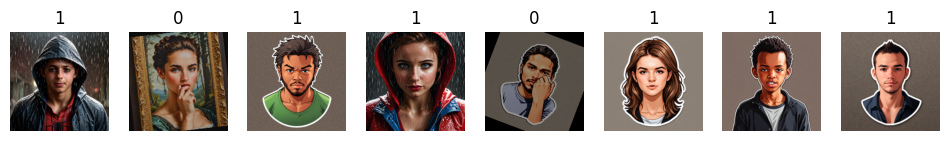

In [ ]:
show_augmented_examples(train_dataset)

## Build the CNN model

To classify artifact images, a custom Convolutional Neural Network (CNN) is defined with at least 3 convolutional layers. The architecture is designed to extract hierarchical features while handling image variations and imbalances.

In [ ]:
# Artifact CNN model (>=3 conv layers)

class ArtifactCNN(nn.Module):
  def __init__(self, num_classes=2):
    super(ArtifactCNN, self).__init__()
    self.feature_extractor = nn.Sequential(
        # First conv layer: 3 input channels (RGB), 16 output channels
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ELU(),
        nn.MaxPool2d(2), # 112
        nn.Dropout(0.2),

        # Second conv layer: 16 -> 32 channels
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ELU(),
        nn.MaxPool2d(2), # 56
        nn.Dropout(0.3),

        # Third conv layer: 32 -> 64 channels
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ELU(),
        nn.MaxPool2d(2), # 28
        nn.Dropout(0.4),

        # Optional: fourth conv layer
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ELU(),
        nn.MaxPool2d(2),
        nn.Dropout(0.5),

        nn.AdaptiveAvgPool2d((7,7)),
        nn.Flatten(),
    )

    self.classifier = nn.Sequential(
            nn.Linear(128*7*7, 256),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

  def forward(self, x):
    x = self.feature_extractor(x)
    x = self.classifier(x)
    return x

**Model Instantiation**

In [ ]:
model_cnn = ArtifactCNN(num_classes=2).to(DEVICE)

## Initializing ResNet18

In addition to the custom CNN, a predefined ResNet-18 model is instantiated to leverage a deeper architecture with residual connections for artifact classification.

In [ ]:
model_res = models.resnet18(pretrained=False)
num_ftrs = model_res.fc.in_features
model_res.fc = nn.Linear(num_ftrs, 2)  # 2 classes
model_res = model_res.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## Help train and val functions

In [ ]:
# Utility: train/validate loops

def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0
  preds_all, labels_all = [], []

  for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * imgs.size(0)

    preds = outputs.argmax(dim=1)
    preds_all.extend(preds.cpu().numpy())
    labels_all.extend(labels.cpu().numpy())

  epoch_loss = running_loss / len(loader.dataset)
  epoch_f1 = f1_score(labels_all, preds_all, average='micro')
  #epoch_mcc = matthews_corrcoef(labels_all, preds_all)
  #epoch_bal_acc = balanced_accuracy_score(labels_all, preds_all)
  cm_train = confusion_matrix(labels_all, preds_all)
  return epoch_loss, epoch_f1, cm_train

In [ ]:
def validate(model, loader, criterion, device):
  model.eval()
  running_loss = 0
  preds_all, labels_all = [], []

  with torch.no_grad():
    for imgs, labels in loader:
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * imgs.size(0)
      preds = outputs.argmax(dim=1)
      preds_all.extend(preds.cpu().numpy())
      labels_all.extend(labels.cpu().numpy())

  epoch_loss = running_loss / len(loader.dataset)
  epoch_f1 = f1_score(labels_all, preds_all, average='micro')
  #epoch_mcc = matthews_corrcoef(labels_all, preds_all)
  #epoch_bal_acc = balanced_accuracy_score(labels_all, preds_all)
  cm_val = confusion_matrix(labels_all, preds_all)
  return epoch_loss, epoch_f1, cm_val

In [ ]:
# Training manager with saving best model and logging

def run_training(model, train_loader, val_loader, epochs=10, lr=1e-4, save_path="/content/best_model.pth"):
  model.to(DEVICE)

  labels_tensor = torch.tensor(train_labels)
  class_counts = torch.bincount(labels_tensor)
  class_weights = 1.0 / class_counts.float()

  criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
  optimizer = optim.Adam(model.parameters(), lr=lr)

  best_val_f1 = 0.0
  history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
  for epoch in range(epochs):
    train_loss, train_f1, train_cm = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_f1, val_cm = validate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f" Train Loss: {train_loss:.4f}, F1: {train_f1:.4f}")
    print(f" Val Loss:   {val_loss:.4f}, F1: {val_f1:.4f}")
    print(" Confusion Matrix (Train):")
    print(train_cm)
    print(" Confusion Matrix (Val):")
    print(val_cm)

    # Save the best model
    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      torch.save({'model_state_dict': model.state_dict(),
                  'optimizer_state_dict': optimizer.state_dict(),
                  'epoch': epoch,
                  'val_f1': val_f1}, save_path)
      print(" ✅ Saved new best model!")

  # Plots
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.plot(history['train_loss'], label='Train Loss')
  plt.plot(history['val_loss'], label='Val Loss')
  plt.legend()
  plt.title('Loss per Epoch')

  plt.subplot(1,2,2)
  plt.plot(history['train_f1'], label='Train F1')
  plt.plot(history['val_f1'], label='Val F1')
  plt.legend()
  plt.title('F1 per Epoch')
  plt.show()

  return model, history

## Train and Validation

## CNN model using F1 metric

### Train


Epoch 1/10
 Train Loss: 0.2214, F1: 0.9361
 Val Loss:   1.1440, F1: 0.8972
 Confusion Matrix (Train):
[[ 127   17]
 [  75 1221]]
 Confusion Matrix (Val):
[[  2  34]
 [  3 321]]
 ✅ Saved new best model!

Epoch 2/10
 Train Loss: 0.2212, F1: 0.9243
 Val Loss:   0.7882, F1: 0.7667
 Confusion Matrix (Train):
[[ 129   15]
 [  94 1202]]
 Confusion Matrix (Val):
[[ 19  17]
 [ 67 257]]

Epoch 3/10
 Train Loss: 0.1874, F1: 0.9472
 Val Loss:   1.4429, F1: 0.8972
 Confusion Matrix (Train):
[[ 131   13]
 [  63 1233]]
 Confusion Matrix (Val):
[[  1  35]
 [  2 322]]

Epoch 4/10
 Train Loss: 0.1678, F1: 0.9563
 Val Loss:   0.9055, F1: 0.7472
 Confusion Matrix (Train):
[[ 129   15]
 [  48 1248]]
 Confusion Matrix (Val):
[[ 18  18]
 [ 73 251]]

Epoch 5/10
 Train Loss: 0.1907, F1: 0.9479
 Val Loss:   0.8888, F1: 0.7528
 Confusion Matrix (Train):
[[ 129   15]
 [  60 1236]]
 Confusion Matrix (Val):
[[ 14  22]
 [ 67 257]]

Epoch 6/10
 Train Loss: 0.1291, F1: 0.9632
 Val Loss:   0.8861, F1: 0.7167
 Confusio

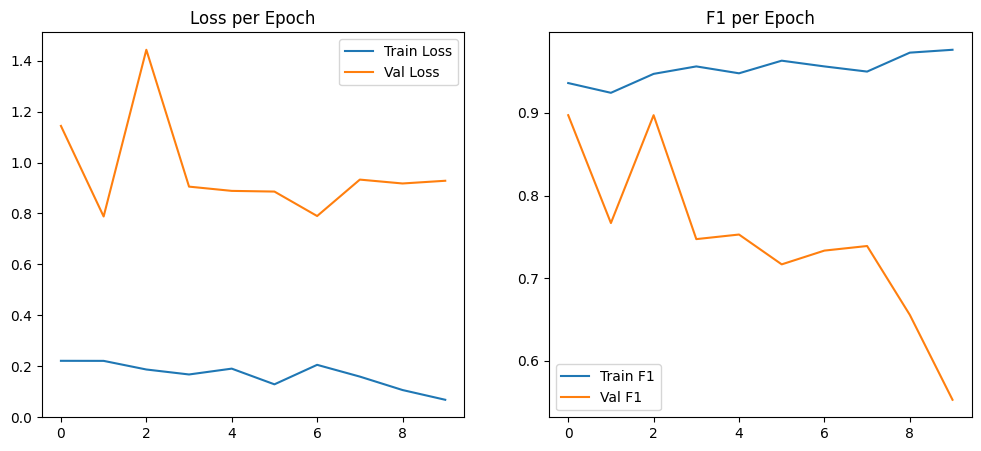

In [ ]:
trained_model_cnn, history_cnn = run_training(model_cnn, train_loader, val_loader, epochs=10, lr=1e-4, save_path="/content/best_model_cnn.pth")

The model was trained for 10 epochs on a highly imbalanced dataset (class 0: minority, class 1: majority). The reported metrics include train/validation loss, F1 scores, and confusion matrices.

**Training Performance**

* Loss steadily decreases on the training set: Starts at 0.2214 → ends at 0.0684.

* F1 score on training improves: Starts at 0.9361 → ends at 0.9764.

Confusion matrices show that:
* The model predicts the majority class (class 1) very well.
* Minority class (class 0) predictions improve gradually but remain challenging.

Model is learning effectively on the training data.

High F1 score indicates strong overall performance, but the class imbalance still influences the predictions.

**Validation Performance**

* Validation loss fluctuates: Between 0.7167 and 1.4429.
Not strictly decreasing, suggesting overfitting to the training set.

* Validation F1 score drops over epochs: Starts high at 0.8972 → drops to 0.5528 by epoch 10.

Confusion matrices reveal:

* Many false negatives for the minority class (class 0).

**Epoch 1 (best F1 on validation):**

Val Confusion Matrix:

```
[[ 2 34]
 [ 3 321]]
```

* Class 0 is under-predicted (2/36 correct), class 1 is mostly correct.

* Even at best F1, the minority class is poorly recognized.

**Epoch 10:**

Val Confusion Matrix:
```
[[22 14]
 [147 177]]
```
* Model starts predicting class 0 more often, but at the cost of misclassifying many class 1 samples.

* Shows trade-off between sensitivity to minority class vs. accuracy on majority class.

### Test

After training, it is often useful to load the best-performing model (based on validation F1) for evaluation or deployment.

In [ ]:
checkpoint_cnn = torch.load("/content/best_model_cnn.pth", map_location=DEVICE)
model_cnn.load_state_dict(checkpoint_cnn['model_state_dict'])
model_cnn.eval()
print(f"Loaded model from epoch {checkpoint_cnn['epoch']} with F1={checkpoint_cnn['val_f1']:.4f}")

Loaded model from epoch 0 with F1=0.8972


In [ ]:
criterion = nn.CrossEntropyLoss()

test_loss_cnn, test_f1_cnn, test_cm_cnn = validate(model_cnn, test_loader, criterion, DEVICE)

print("\n=== Test results ===")
print(f"Test Loss: {test_loss_cnn:.4f}")
print(f"Test F1:   {test_f1_cnn:.4f}")
print("Confusion Matrix (Test):")
print(test_cm_cnn)


=== Test results ===
Test Loss: 0.3605
Test F1:   0.8900
Confusion Matrix (Test):
[[  0  20]
 [  2 178]]


* Model generalizes reasonably well to the majority class.

* Minority class (class 0) is still poorly recognized on the test set.

Despite limitations, the model provides a baseline benchmark for artifact detection on this dataset.

## ResNet18 using F1 metric

### Train


Epoch 1/10
 Train Loss: 0.6640, F1: 0.8090
 Val Loss:   1.0205, F1: 0.6083
 Confusion Matrix (Train):
[[ 107   37]
 [ 238 1058]]
 Confusion Matrix (Val):
[[ 14  22]
 [119 205]]
 ✅ Saved new best model!

Epoch 2/10
 Train Loss: 0.2176, F1: 0.9368
 Val Loss:   0.7827, F1: 0.8500
 Confusion Matrix (Train):
[[ 134   10]
 [  81 1215]]
 Confusion Matrix (Val):
[[ 14  22]
 [ 32 292]]
 ✅ Saved new best model!

Epoch 3/10
 Train Loss: 0.1433, F1: 0.9556
 Val Loss:   1.5231, F1: 0.9028
 Confusion Matrix (Train):
[[ 136    8]
 [  56 1240]]
 Confusion Matrix (Val):
[[  3  33]
 [  2 322]]
 ✅ Saved new best model!

Epoch 4/10
 Train Loss: 0.1238, F1: 0.9611
 Val Loss:   1.2843, F1: 0.8611
 Confusion Matrix (Train):
[[ 136    8]
 [  48 1248]]
 Confusion Matrix (Val):
[[  9  27]
 [ 23 301]]

Epoch 5/10
 Train Loss: 0.1056, F1: 0.9632
 Val Loss:   3.3975, F1: 0.8972
 Confusion Matrix (Train):
[[ 138    6]
 [  47 1249]]
 Confusion Matrix (Val):
[[  0  36]
 [  1 323]]

Epoch 6/10
 Train Loss: 0.0951, F1

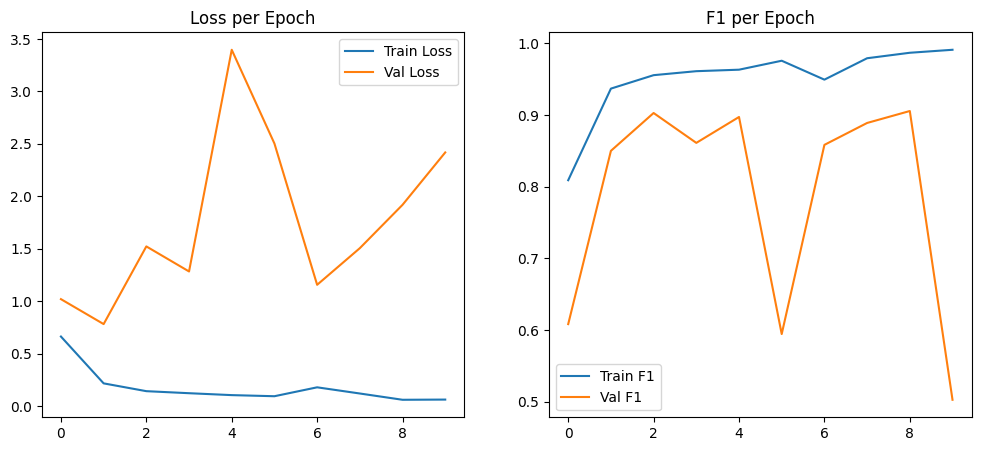

In [ ]:
trained_model_res, history_res = run_training(model_res, train_loader, val_loader, epochs=10, lr=1e-3, save_path="/content/best_model_res.pth")

**Training Performance**

* Train Loss: steadily decreases from 0.6640 → 0.0631.

* Train F1 Score: rises from 0.8090 → 0.9910.

Confusion Matrices:

* The model predicts majority class (class 1) very accurately.

* Minority class (class 0) predictions improve slightly but remain underrepresented in some epochs.

**Validation Performance**

* Validation Loss: fluctuates significantly (0.6083 → 2.4190).

* Validation F1: peaks at 0.9056 (epoch 9) but drops to 0.5028 by epoch 10.

Confusion Matrices:

* Minority class (class 0) is frequently misclassified.

* Majority class (class 1) is mostly correct but occasionally misclassified when the model tries to adjust for class 0.

Peak F1 occurs before final epoch, suggesting early stopping could improve generalization.

**Observations from Confusion Matrices**

**Early epochs:**
minority class predictions are very low → high false negatives.

**Middle epochs:**
model improves minority class recognition (epoch 3, F1=0.9028).

**Late epochs:**
extreme overfitting to training set reduces validation F1 (epoch 10, F1=0.5028).

Confirms a trade-off between learning minority class vs. generalization.

### Comparison to Custom CNN

**1. Model Architecture & Capacity**
* Custom CNN is simpler, designed to learn features with fewer parameters.

* ResNet-18 has higher capacity and uses residual connections, which help with learning deeper features but can also cause faster overfitting on small datasets.

**2. Training Performance**


Custom CNN:

* Training F1 reached ~0.976, showing strong learning on the training set.

* Validation F1 peaked around 0.897, then declined slightly due to overfitting.

ResNet-18:

* Training F1 reached ~0.991, slightly higher due to more parameters.

* Validation F1 peaked around 0.905, but then dropped sharply to 0.5028 by the last epoch.




### Test

In [ ]:
checkpoint_res = torch.load("/content/best_model_res.pth", map_location=DEVICE)
model_res.load_state_dict(checkpoint_res['model_state_dict'])
model_res.eval()
print(f"Loaded model from epoch {checkpoint_res['epoch']} with F1={checkpoint_res['val_f1']:.4f}")

Loaded model from epoch 8 with F1=0.9056


In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss_res, test_f1_res, test_cm_res = validate(model_res, test_loader, criterion, DEVICE)

print("\n=== Test results ===")
print(f"Test Loss: {test_loss_res:.4f}")
print(f"Test F1:   {test_f1_res:.4f}")
print("Confusion Matrix (Test):")
print(test_cm_res)


=== Test results ===
Test Loss: 0.4643
Test F1:   0.9000
Confusion Matrix (Test):
[[  0  20]
 [  0 180]]


All minority class samples (class 0) were misclassified as class 1.

Majority class (class 1) predictions are perfect.

Highlights that class imbalance is still the limiting factor, despite the deeper ResNet-18 architecture.

## Different metrics

**MCC (Matthews Correlation Coefficient)** is a classification quality metric that is often used for binary tasks, especially when classes are imbalanced.

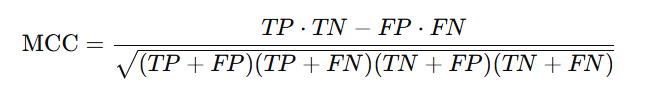

MCC ∈ [-1, 1]

1 → perfect classification

0 → chance prediction

-1 → completely opposite predictions

Takes into account all four values of the confusion matrix (TP, TN, FP, FN)

Makes it particularly useful for imbalanced classes, where simple F1 or Accuracy can give misleading results

**Balanced Accuracy**

It's is a classification metric that is particularly useful when classes are unbalanced. It equalizes the contribution of each class so that the dominant class does not “pull the blanket.”

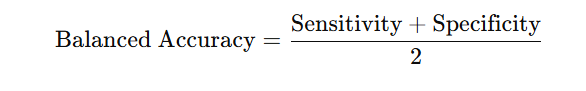

Value ∈ [0, 1]

1 → perfect classification

0.5 → random prediction for binary imbalance (classical Accuracy for random predictions can be misleading)

Particularly useful when one class is significantly larger than the other

### Defining new help functions for MCC and Balanced accuracy

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, matthews_corrcoef, balanced_accuracy_score, average_precision_score, roc_auc_score

In [ ]:
# Utility: train/validate loops

def train_one_epoch_m(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0
  preds_all, labels_all = [], []

  for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * imgs.size(0)

    preds = outputs.argmax(dim=1)
    preds_all.extend(preds.cpu().numpy())
    labels_all.extend(labels.cpu().numpy())

  epoch_loss = running_loss / len(loader.dataset)
  #epoch_f1 = f1_score(labels_all, preds_all, average='micro')
  epoch_mcc = matthews_corrcoef(labels_all, preds_all)
  epoch_bal_acc = balanced_accuracy_score(labels_all, preds_all)
  cm_train = confusion_matrix(labels_all, preds_all)
  return epoch_loss, epoch_mcc, epoch_bal_acc, cm_train

In [ ]:
def validate_m(model, loader, criterion, device):
  model.eval()
  running_loss = 0
  preds_all, labels_all = [], []

  with torch.no_grad():
    for imgs, labels in loader:
      imgs, labels = imgs.to(device), labels.to(device)
      outputs = model(imgs)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * imgs.size(0)
      preds = outputs.argmax(dim=1)
      preds_all.extend(preds.cpu().numpy())
      labels_all.extend(labels.cpu().numpy())

  epoch_loss = running_loss / len(loader.dataset)
  #epoch_f1 = f1_score(labels_all, preds_all, average='micro')
  epoch_mcc = matthews_corrcoef(labels_all, preds_all)
  epoch_bal_acc = balanced_accuracy_score(labels_all, preds_all)
  cm_val = confusion_matrix(labels_all, preds_all)
  return epoch_loss, epoch_mcc, epoch_bal_acc, cm_val

In [ ]:
# Training manager with saving best model and logging

def run_training_m(model, train_loader, val_loader, epochs=10, lr=1e-4, save_path="/content/best_model.pth"):
  model.to(DEVICE)

  labels_tensor = torch.tensor(train_labels)
  class_counts = torch.bincount(labels_tensor)
  class_weights = 1.0 / class_counts.float()

  criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
  optimizer = optim.Adam(model.parameters(), lr=lr)

  best_val_mcc = 0.0
  history = {'train_loss': [], 'train_mcc': [],'train_bal_acc': [], 'val_loss': [], 'val_mcc': [], 'val_bal_acc': []}
  for epoch in range(epochs):
    train_loss, train_mcc, train_bal_acc, train_cm = train_one_epoch_m(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_mcc, val_bal_acc, val_cm = validate_m(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mcc'].append(train_mcc)
    history['val_mcc'].append(val_mcc)
    history['train_bal_acc'].append(train_bal_acc)
    history['val_bal_acc'].append(val_bal_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f" Train Loss: {train_loss:.4f}, MCC: {train_mcc:.4f}, Balanced Accuracy: {train_bal_acc:.4f}")
    print(f" Val Loss:   {val_loss:.4f}, MCC: {val_mcc:.4f},  Balanced Accuracy: {val_bal_acc:.4f}")
    print(" Confusion Matrix (Train):")
    print(train_cm)
    print(" Confusion Matrix (Val):")
    print(val_cm)

    # Save the best model
    if val_mcc > best_val_mcc:
      best_val_mcc = val_mcc
      torch.save({'model_state_dict': model.state_dict(),
                  'optimizer_state_dict': optimizer.state_dict(),
                  'epoch': epoch,
                  'val_mcc': val_mcc}, save_path)
      print(" ✅ Saved new best model!")

  # Plots
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.plot(history['train_loss'], label='Train Loss')
  plt.plot(history['val_loss'], label='Val Loss')
  plt.legend()
  plt.title('Loss per Epoch')

  plt.subplot(1,2,2)
  plt.plot(history['train_mcc'], label='Train MCC')
  plt.plot(history['val_mcc'], label='Val MCC')
  plt.legend()
  plt.title('MCC per Epoch')
  plt.show()

  return model, history

### Train CNN using MCC


Epoch 1/10
 Train Loss: 0.7976, MCC: 0.1766, Balanced Accuracy: 0.6416
 Val Loss:   0.7883, MCC: 0.0652,  Balanced Accuracy: 0.5170
 Confusion Matrix (Train):
[[ 89  55]
 [434 862]]
 Confusion Matrix (Val):
[[  2  34]
 [  7 317]]
 ✅ Saved new best model!

Epoch 2/10
 Train Loss: 0.3129, MCC: 0.6058, Balanced Accuracy: 0.8750
 Val Loss:   1.1647, MCC: 0.1245,  Balanced Accuracy: 0.5324
 Confusion Matrix (Train):
[[ 121   23]
 [ 117 1179]]
 Confusion Matrix (Val):
[[  3  33]
 [  6 318]]
 ✅ Saved new best model!

Epoch 3/10
 Train Loss: 0.2436, MCC: 0.7273, Balanced Accuracy: 0.9174
 Val Loss:   1.0755, MCC: 0.0997,  Balanced Accuracy: 0.5123
 Confusion Matrix (Train):
[[ 128   16]
 [  70 1226]]
 Confusion Matrix (Val):
[[  1  35]
 [  1 323]]

Epoch 4/10
 Train Loss: 0.2554, MCC: 0.6581, Balanced Accuracy: 0.8939
 Val Loss:   0.7492, MCC: 0.3108,  Balanced Accuracy: 0.6821
 Confusion Matrix (Train):
[[ 124   20]
 [  95 1201]]
 Confusion Matrix (Val):
[[ 17  19]
 [ 35 289]]
 ✅ Saved new b

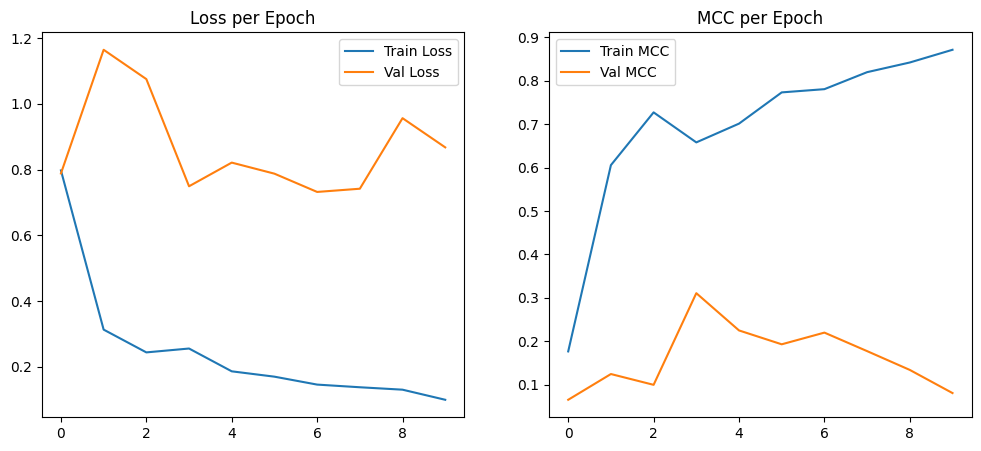

In [ ]:
trained_modelm_cnn, historym_cnn = run_training_m(model_cnn, train_loader, val_loader, epochs=10, lr=1e-4, save_path="/content/best_model_cnn_m.pth")

**Training Performance**

During training, both MCC and Balanced Accuracy increased steadily:

* MCC improved from 0.17 → 0.87

* Balanced Accuracy improved from 0.64 → 0.96

This shows that during training the model learned to correctly classify both classes and did not simply memorize the majority class.

**Validation Performance**

Validation trends are very different from training:

**MCC on validation:**

* Starts near 0.06

* Peaks at 0.31 at epoch 4 (the best performing epoch)

* Drops back to 0.08 by epoch 10

**Balanced Accuracy on validation:**

* Fluctuates heavily

* Peaks at 0.68 (epoch 4)

* Returns to ~0.56–0.62 afterwards

Training metrics rise, but validation metrics do not follow, indicating overfitting.

Fluctuations show that performance is unstable and heavily depends on the imbalance in each mini-batch.


**Conclusion**

Even though the training results appear strong, validation results reveal that the model struggles with generalizing to the minority class. The MCC and Balanced Accuracy metrics clearly show that the strongest model behavior occurs around epoch 4, after which the model overfits and degenerates into majority-class prediction.

However, the MCC > 0.3 at epoch 4 is a promising signal, indicating that the model is capable of learning discriminative features but needs improved training strategy to handle imbalance.

### Test CNN

In [ ]:
checkpoint_cnn_m = torch.load("/content/best_model_cnn_m.pth", map_location=DEVICE, weights_only=False)
model_cnn.load_state_dict(checkpoint_cnn_m['model_state_dict'])
model_cnn.eval()
print(f"Loaded model from epoch {checkpoint_cnn_m['epoch']} with MCC={checkpoint_cnn_m['val_mcc']:.4f}")

Loaded model from epoch 3 with MCC=0.3108


In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss_m, test_mcc_m, test_bal_acc_m, test_cm_m = validate_m(model_cnn, test_loader, criterion, DEVICE)

print("\n=== Test results ===")
print(f"Test Loss: {test_loss_m:.4f}")
print(f"Test MCC:  {test_mcc_m:.4f}")
print(f"Test Balanced Accuracy:  {test_bal_acc_m:.4f}")
print("Confusion Matrix (Test):")
print(test_cm_m)


=== Test results ===
Test Loss: 0.4137
Test MCC:  0.0756
Test Balanced Accuracy:  0.5417
Confusion Matrix (Test):
[[  4  16]
 [ 21 159]]


The obtained value MCC = 0.0756 is very low and close to 0, indicating that the model’s predictions were only slightly better than random chance. This is consistent with the confusion matrix, which shows that the model struggled particularly with detecting the minority class

**Comparison with F1-score Results**

**Why MCC Is a Better Indicator in This Case**

MCC penalizes such imbalanced behavior and therefore provides a more realistic picture:

* It shows that although F1 appears strong, the classifier is biased toward the majority class.

* MCC reveals that minority class detection is weak.

* MCC and Balanced Accuracy highlight that the classifier is not generalizing well across both classes.

MCC and Balanced Accuracy provide a more reliable evaluation, showing that the model needs improvement—either through better balancing strategies, more representative data, or stronger architectures.

### Train ResNet18 using MCC


Epoch 1/10
 Train Loss: 0.7649, MCC: 0.3264, Balanced Accuracy: 0.7434
 Val Loss:   0.8351, MCC: 0.1737,  Balanced Accuracy: 0.6127
 Confusion Matrix (Train):
[[ 103   41]
 [ 296 1000]]
 Confusion Matrix (Val):
[[ 14  22]
 [ 53 271]]
 ✅ Saved new best model!

Epoch 2/10
 Train Loss: 0.1659, MCC: 0.7793, Balanced Accuracy: 0.9425
 Val Loss:   0.7012, MCC: 0.2417,  Balanced Accuracy: 0.6682
 Confusion Matrix (Train):
[[ 134   10]
 [  59 1237]]
 Confusion Matrix (Val):
[[ 19  17]
 [ 62 262]]
 ✅ Saved new best model!

Epoch 3/10
 Train Loss: 0.1142, MCC: 0.8259, Balanced Accuracy: 0.9552
 Val Loss:   1.4988, MCC: 0.2003,  Balanced Accuracy: 0.5849
 Confusion Matrix (Train):
[[ 136    8]
 [  44 1252]]
 Confusion Matrix (Val):
[[  8  28]
 [ 17 307]]

Epoch 4/10
 Train Loss: 0.1039, MCC: 0.8368, Balanced Accuracy: 0.9568
 Val Loss:   2.9910, MCC: 0.0000,  Balanced Accuracy: 0.5000
 Confusion Matrix (Train):
[[ 136    8]
 [  40 1256]]
 Confusion Matrix (Val):
[[  0  36]
 [  0 324]]

Epoch 5/1

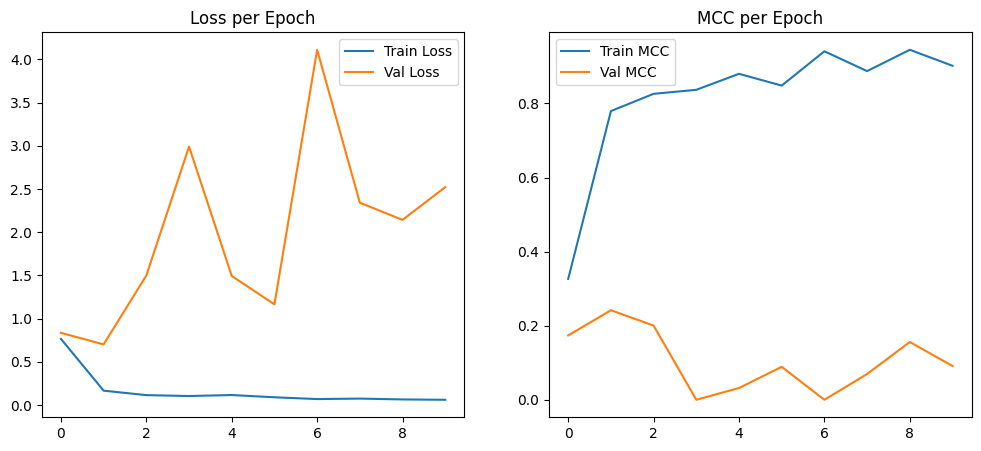

In [ ]:
trained_model_res_m, history_res_m = run_training_m(model_res, train_loader, val_loader, epochs=10, lr=1e-3, save_path="/content/best_model_res_m.pth")

**Training performance** increases steadily, reaching near-perfect MCC and Balanced Accuracy.

**Validation performance** is highly unstable, oscillating between reasonable values and total collapse (predicting only one class).

These results emphasize that for imbalanced tasks, MCC is a much more reliable selection criterion than F1 or accuracy. They also highlight the need for:

* oversampling or class weighting,

* stronger regularization,

* or more domain-specific pretraining.

### Test ResNet18

In [ ]:
checkpoint_res_m = torch.load("/content/best_model_res_m.pth", map_location=DEVICE, weights_only=False)
model_res.load_state_dict(checkpoint_res_m['model_state_dict'])
model_res.eval()
print(f"Loaded model from epoch {checkpoint_res_m['epoch']} with MCC={checkpoint_res_m['val_mcc']:.4f}")

Loaded model from epoch 1 with MCC=0.2417


In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss_rm, test_mcc_rm, test_bal_acc_rm, test_cm_rm = validate_m(model_res, test_loader, criterion, DEVICE)

print("\n=== Test results ===")
print(f"Test Loss: {test_loss_rm:.4f}")
print(f"Test MCC:  {test_mcc_rm:.4f}")
print(f"Test Balanced Accuracy:  {test_bal_acc_rm:.4f}")
print("Confusion Matrix (Test):")
print(test_cm_rm)


=== Test results ===
Test Loss: 0.5782
Test MCC:  0.1796
Test Balanced Accuracy:  0.6250
Confusion Matrix (Test):
[[  9  11]
 [ 36 144]]


Since MCC considers all four confusion matrix components, the large number of false negatives (36) strongly reduces the score. Therefore, MCC = 0.18 indicates weak reliability in balanced or sensitive classification settings.

Balanced Accuracy = 0.625 similarly suggests that the model performs moderately better than random but still lacks stable minority-class detection.

## Conclusion

The goal of this project was to train and evaluate two convolution-based architectures—a custom CNN and a ResNet-18 model—for a binary image classification task with a highly imbalanced dataset. Throughout the experiments, the models were assessed using multiple metrics, including F1-score, Matthews Correlation Coefficient (MCC), Balanced Accuracy, and confusion matrices, in order to better understand their performance under class imbalance.

Both models achieved high F1-scores (≈0.90), mainly due to accurate predictions of the majority class. However, MCC and Balanced Accuracy revealed that the models struggled with the minority class, highlighting limitations not visible from F1 alone.

The custom CNN and ResNet-18 performed similarly: they reliably classified the majority class but produced many false negatives for the minority class. MCC-based evaluation confirmed that overall balanced performance was moderate (CNN MCC ≈ 0.08, ResNet MCC ≈ 0.18). These results emphasize that F1-score can be misleading in imbalanced scenarios, and metrics like MCC and Balanced Accuracy provide a more realistic assessment.

Despite the challenges, the project successfully implemented, trained, and analyzed both models, providing a foundation for future improvements. Potential enhancements include class balancing, weighted loss functions, and targeted augmentation to improve minority-class detection.